# MLP Algorithm for CICIDS-2017 Dataset
Generated from `MLP_final.py` with optimized sampling (fraction=0.3), standardized evaluation, and SHAP analysis.

In [1]:
import time
import os
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from collections import Counter
from sklearn import metrics
import shap
import warnings
warnings.filterwarnings('ignore')
np.random.seed(0)

In [2]:
req_cols = [ ' Packet Length Std', ' Total Length of Bwd Packets', ' Subflow Bwd Bytes',
 ' Destination Port', ' Packet Length Variance', ' Bwd Packet Length Mean',' Avg Bwd Segment Size',
 'Bwd Packet Length Max', ' Init_Win_bytes_backward','Total Length of Fwd Packets',
 ' Subflow Fwd Bytes', 'Init_Win_bytes_forward', ' Average Packet Size', ' Packet Length Mean',
 ' Max Packet Length',' Label']

db_path = '../cicids_db/'
files = [
    'Wednesday-workingHours.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Monday-WorkingHours.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'
]

frames = []
for f in files:
    path = os.path.join(db_path, f)
    if os.path.exists(path):
        print(f'Loading {f}...')
        df_tmp = pd.read_csv(path, usecols=req_cols, low_memory=False, encoding='cp1252')
        frames.append(df_tmp)

df = pd.concat(frames, ignore_index=True)
# Using 0.3 fraction as requested
df = df.sample(frac=0.3, random_state=0)
print('Total samples loaded:', len(df))

Loading Wednesday-workingHours.pcap_ISCX.csv...
Loading Tuesday-WorkingHours.pcap_ISCX.csv...
Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
Loading Monday-WorkingHours.pcap_ISCX.csv...
Loading Friday-WorkingHours-Morning.pcap_ISCX.csv...
Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
Total samples loaded: 935804


In [ ]:
def preprocess_data(df):
    temp_df = df.copy()
    temp_df.columns = temp_df.columns.str.strip()
    
    # Standardize labels and drop spaces
    if 'Label' in temp_df.columns:
        temp_df['Label'] = temp_df['Label'].astype(str).str.strip().replace({
            'DoS GoldenEye': 'Dos/Ddos', 'DoS Hulk': 'Dos/Ddos', 'DoS Slowhttptest': 'Dos/Ddos',
            'DoS slowloris': 'Dos/Ddos', 'Heartbleed': 'Dos/Ddos', 'DDoS': 'Dos/Ddos',
            'FTP-Patator': 'Brute Force', 'SSH-Patator': 'Brute Force',
            'Web Attack - Brute Force': 'Web Attack', 'Web Attack - Sql Injection': 'Web Attack',
            'Web Attack - XSS': 'Web Attack', 'Web Attack XSS': 'Web Attack', 
            'Web Attack Sql Injection': 'Web Attack', 'Web Attack Brute Force': 'Web Attack'
        })

    temp_df.fillna(0, inplace=True)
    X = temp_df.drop(columns=['Label'])
    y = temp_df['Label']
    
    # Max scaling
    for col in X.columns:
        try:
            X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)
            m = X[col].max()
            if m != 0: X[col] = X[col] / m
        except: pass
    return X, y

X, y = preprocess_data(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=0)
y_train_num, label_map = pd.factorize(y_train)
print("Data Split Complete. Training samples:", len(X_train))
print("Label Map:", label_map)

Data Split Complete. Training samples: 655062
Label Map: Index(['BENIGN', 'PortScan', 'nan', 'Dos/Ddos', 'Brute Force',
       'Web Attack – Brute Force', 'Bot', 'Web Attack – XSS', 'Infiltration',
       'Web Attack – Sql Injection'],
      dtype='object')


In [4]:
model = MLPClassifier(random_state=1, max_iter=300)
start = time.time()
model.fit(X_train, y_train)
print(f"ELAPSE TIME MODEL: {(time.time() - start)/60:.2f} min")

ELAPSE TIME MODEL: 26.42 min


In [5]:
y_pred = model.predict(X_test)
y_score = model.predict_proba(X_test)

conf_matrix = pd.crosstab(y_test, y_pred, rownames=['Actual ALERT'], colnames=['Predicted ALERT']).sort_index(axis=0).sort_index(axis=1)
print("Confusion Matrix:")
print(conf_matrix)

print('\nAccuracy:', metrics.accuracy_score(y_test, y_pred))

unique_test_classes = np.unique(y_test.astype(str))
if len(unique_test_classes) > 1:
    indices = [i for i, name in enumerate(label_map) if name in unique_test_classes]
    y_test_bin = label_binarize(y_test, classes=label_map[indices].tolist())
    y_score_filtered = y_score[:, indices]
    try:
        print('ROC-AUC:', metrics.roc_auc_score(y_test_bin, y_score_filtered, multi_class='ovr'))
    except: print('ROC-AUC calculation failed')


Confusion Matrix:
Predicted ALERT             BENIGN  Bot  Brute Force  Dos/Ddos  PortScan  \
Actual ALERT                                                               
BENIGN                      202314    5            2      1936       170   
Bot                            105   63            0         0         0   
Brute Force                    256    0          985         3         0   
Dos/Ddos                       192    0            0     34074         0   
Infiltration                     2    0            0         0         0   
PortScan                        41    0            0         8     14260   
Web Attack – Brute Force       122    0            0         0         0   
Web Attack – Sql Injection       2    0            0         0         0   
Web Attack – XSS                66    0            0         0         0   
nan                              0    0            0         0         0   

Predicted ALERT             Web Attack – Brute Force  Web Attack – XS

Calculating SHAP values for 100 samples using KernelExplainer...


  0%|          | 0/100 [00:00<?, ?it/s]

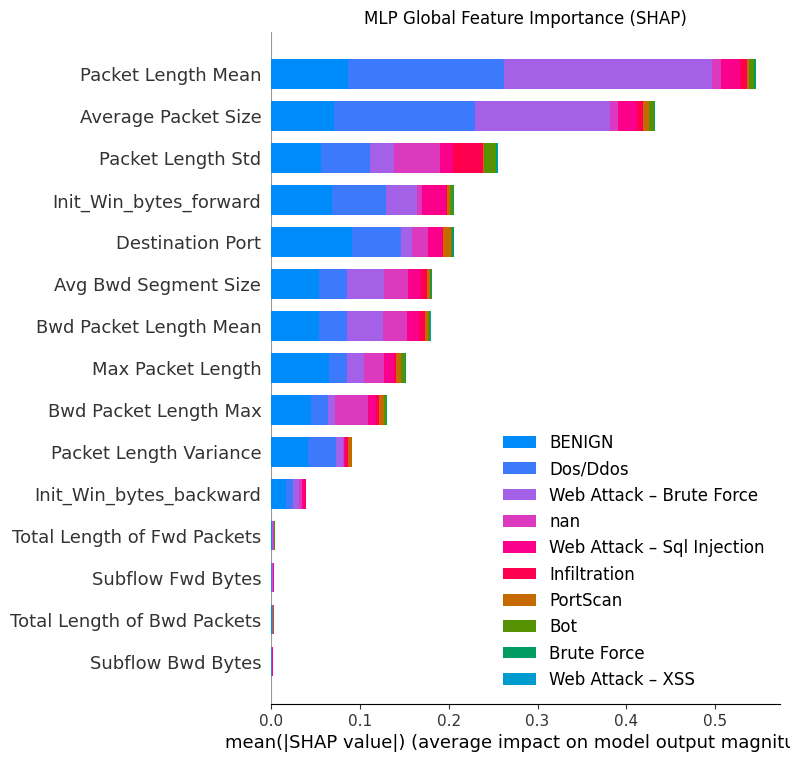

In [6]:
import warnings
warnings.filterwarnings('ignore')

# 1. Prepare data for SHAP
start_index = 0
end_index = 100
test_data_for_shap = X_test.iloc[start_index:end_index]

print(f"Calculating SHAP values for {end_index} samples using KernelExplainer...")

# 2. Initialize Explainer
explainer = shap.KernelExplainer(model.predict_proba, test_data_for_shap)
shap_values = explainer.shap_values(test_data_for_shap)

# 3. Create Global Summary Plot (Stacked Bar)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, test_data_for_shap, class_names=label_map.tolist(), show=False, plot_type='bar')
plt.title("MLP Global Feature Importance (SHAP)")
plt.savefig('MLP_Shap_Summary_global.png', bbox_inches='tight')
plt.show()